In [ ]:
from functools import partial
import numpy as np
from lucifex.fdm import GridFunctionSeries, NPyConstantSeries
from lucifex.fem import grid_average
from lucifex.viz import (
    plot_colormap, plot_line, save_figure, create_multifigure,
    plot_colormap_multifigure, plot_line_multifigure, 
    plot_scatter, scatter_size,
)
from lucifex.utils.array_utils import as_index
from lucifex.io import create_dir_path, find_dir_paths
from lucifex.utils.py_utils import FrozenDict
from lucifex.utils.array_utils import derivative, resample
from lucifex.sim import GridSimulationFromNPZ
from crocodil.dns.system_a import SYSTEM_A_REFERENCE
from .ipynb_utils import as_int_if_poss

# searching for any simulations in the root directory
PARAMS_NUMERICAL = FrozenDict(
    c_stabilization=None,
    c_limits=True,
)
DIR_ROOT = create_dir_path(
    PARAMS_NUMERICAL, 
    dir_root='./',
    dir_prefix='data', 
    dir_params=PARAMS_NUMERICAL.keys(), 
)
DIR_FIGS = f'{DIR_ROOT}/figures'

T_STOP = 120.0
sim_dir_paths = find_dir_paths(
    DIR_ROOT, 
    include=f't_stop={T_STOP}_*',
    contains=('CHECKPOINT.h5', 'c.npz'),
)

# selecting a batch of simulations
sr = 0.2
PARAMS_BATCH = SYSTEM_A_REFERENCE.replace(sr=sr).remove('Ra', 'Da')

simulations_batch = GridSimulationFromNPZ.dict_from_dir_paths(
    ('Ra', 'Da'), 
    sim_dir_paths,
    ('c', 's'),
    ('f', 'mD', 'mC', 'uRMS'),
    PARAMS_BATCH,
    lazy=True,
    sorting=lambda d: dict(sorted(d.items(), reverse=False)),
)

# utilities for plotting
save_figure = partial(
    save_figure, 
    dir_path=DIR_FIGS, 
    prefix=f'Ra_Da_sr={sr}', 
    pickle=True,
    file_ext=('svg', 'png'),
)

In [ ]:
print('Before parameter selection')
for i in sim_dir_paths: print(i)
print('After parameter selection')
for i in simulations_batch.values(): print(i.dir_path)

In [ ]:
# selecting a subset within the batch of simulations
Ra_targets = (500.0, 1000.0, 2000.0)
Da_targets = (1.0, 10.0, 100.0, 1000.0)
include = lambda prm, trgs: prm in trgs if trgs else True
simulations = {
    (Ra, Da): v for (Ra, Da), v in simulations_batch.items()
    if include(Ra, Ra_targets) and include(Da, Da_targets)
}

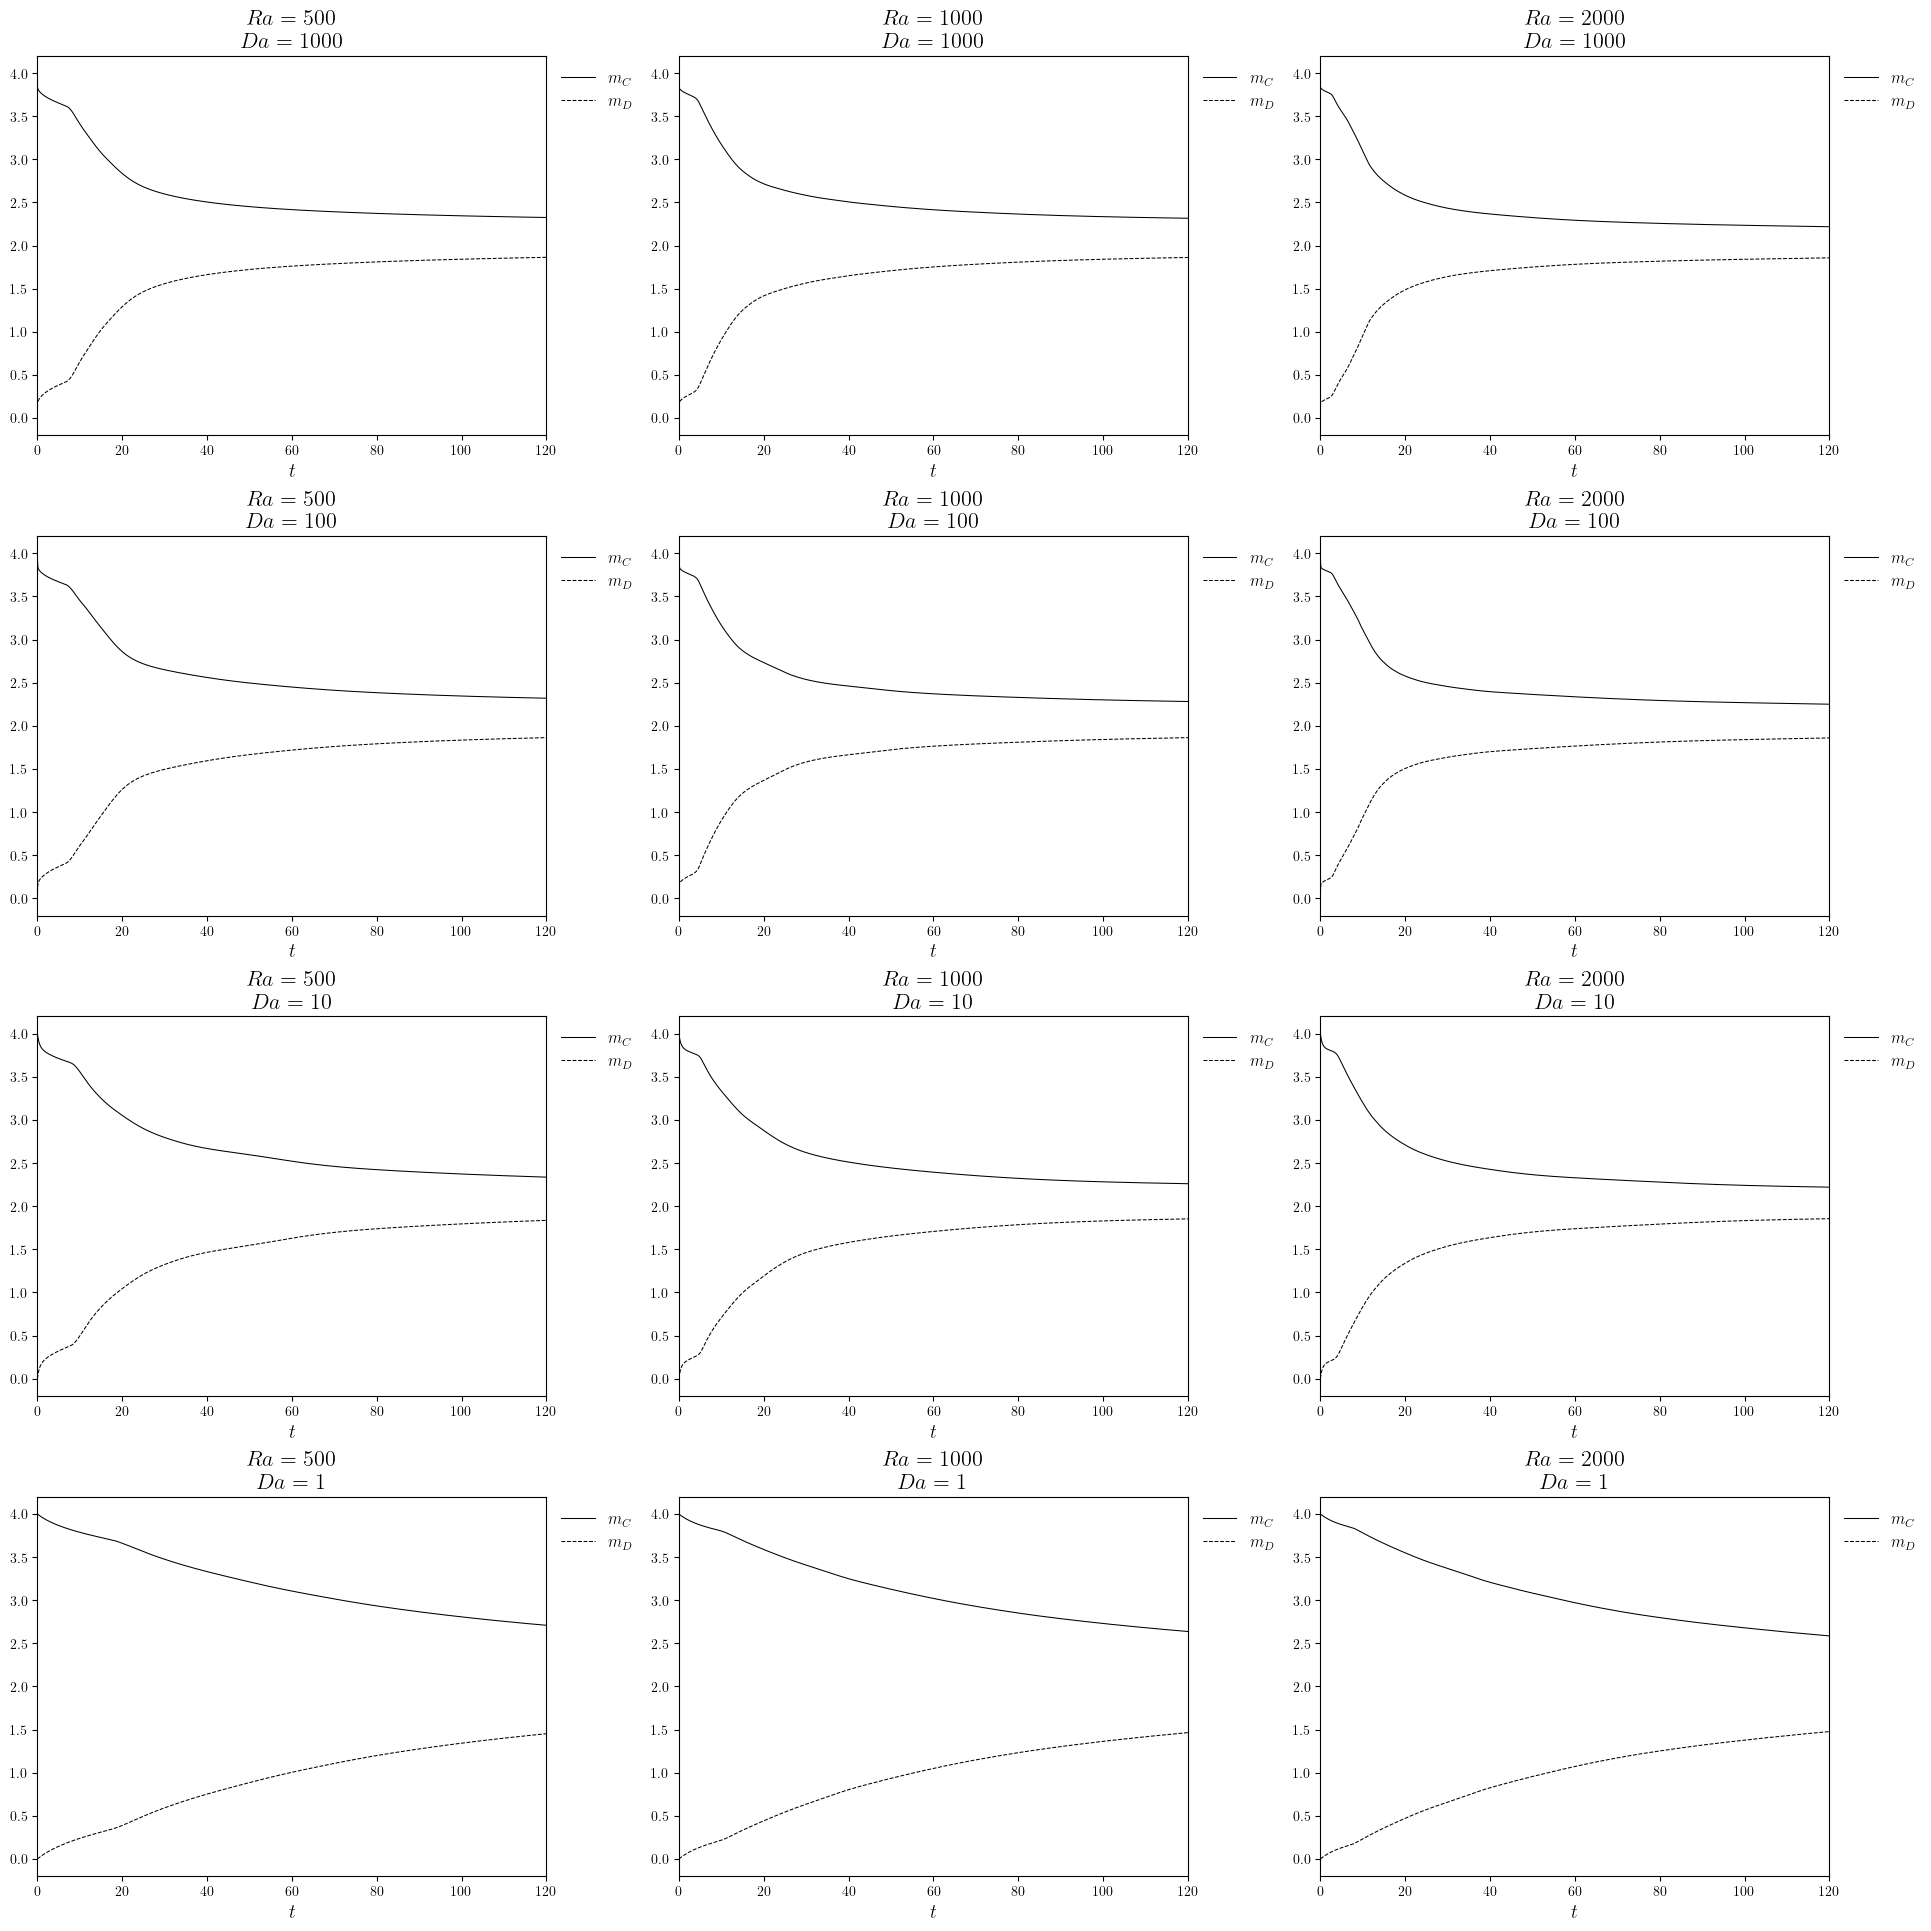

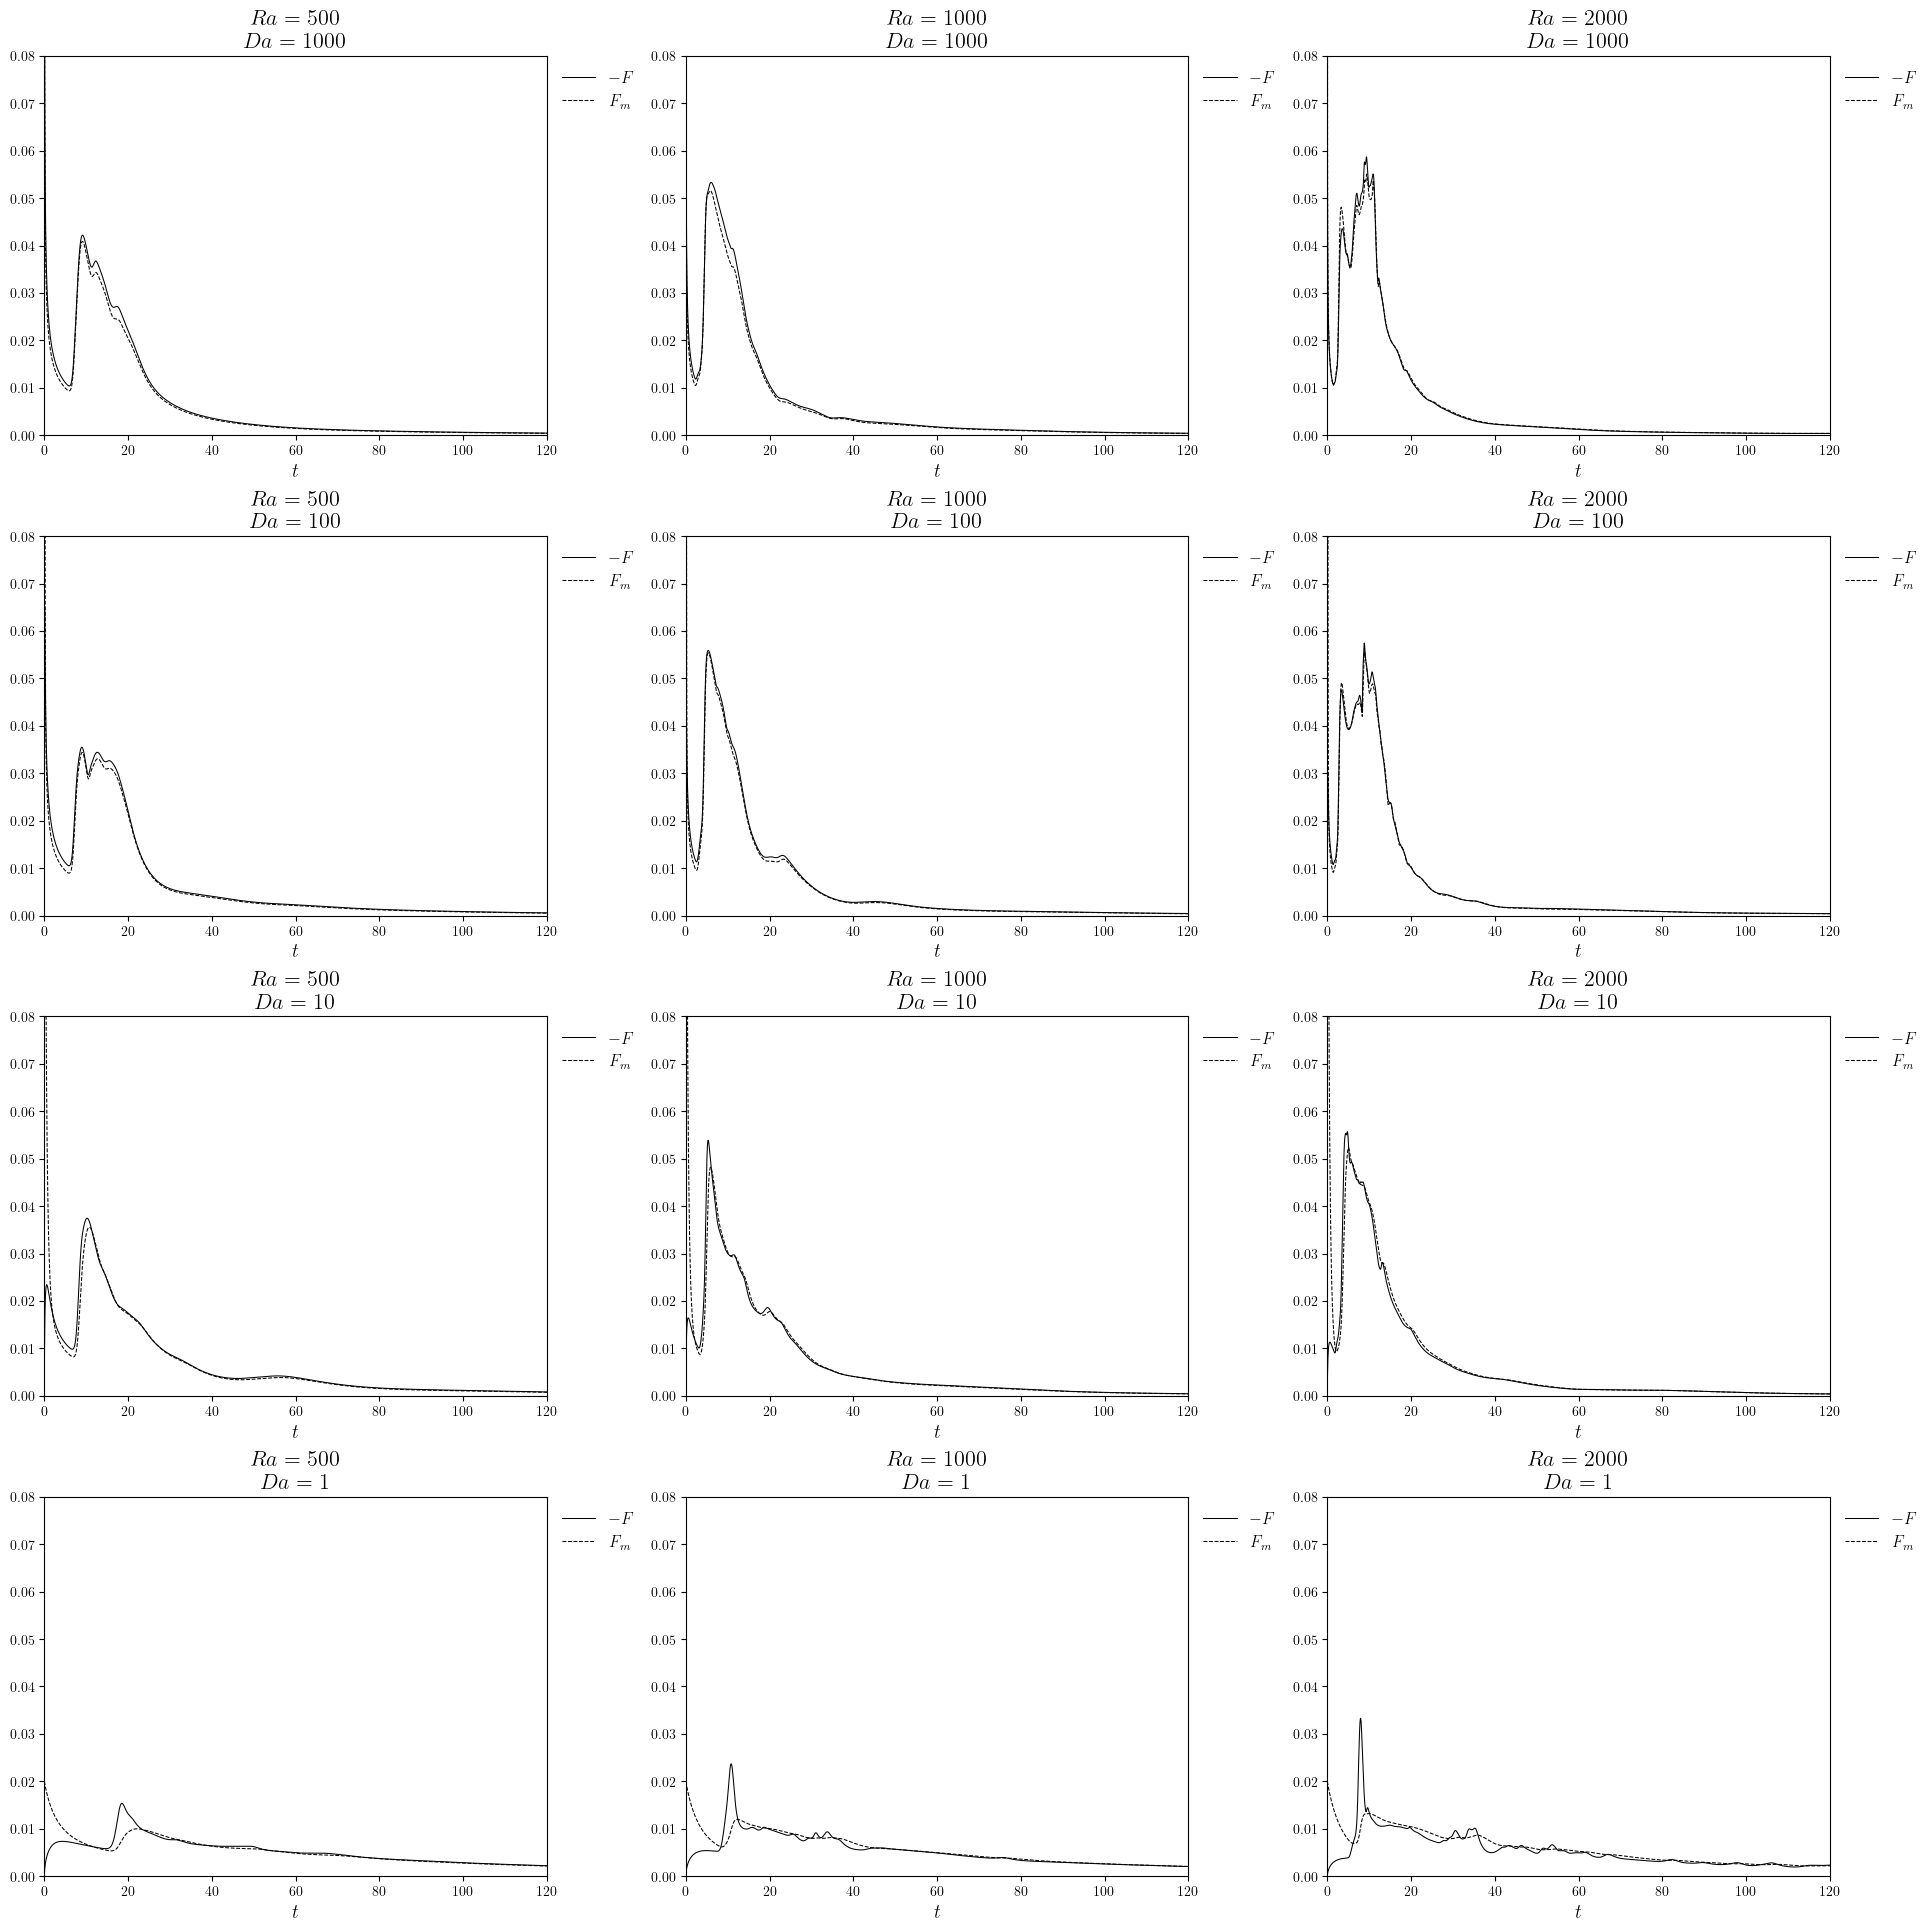

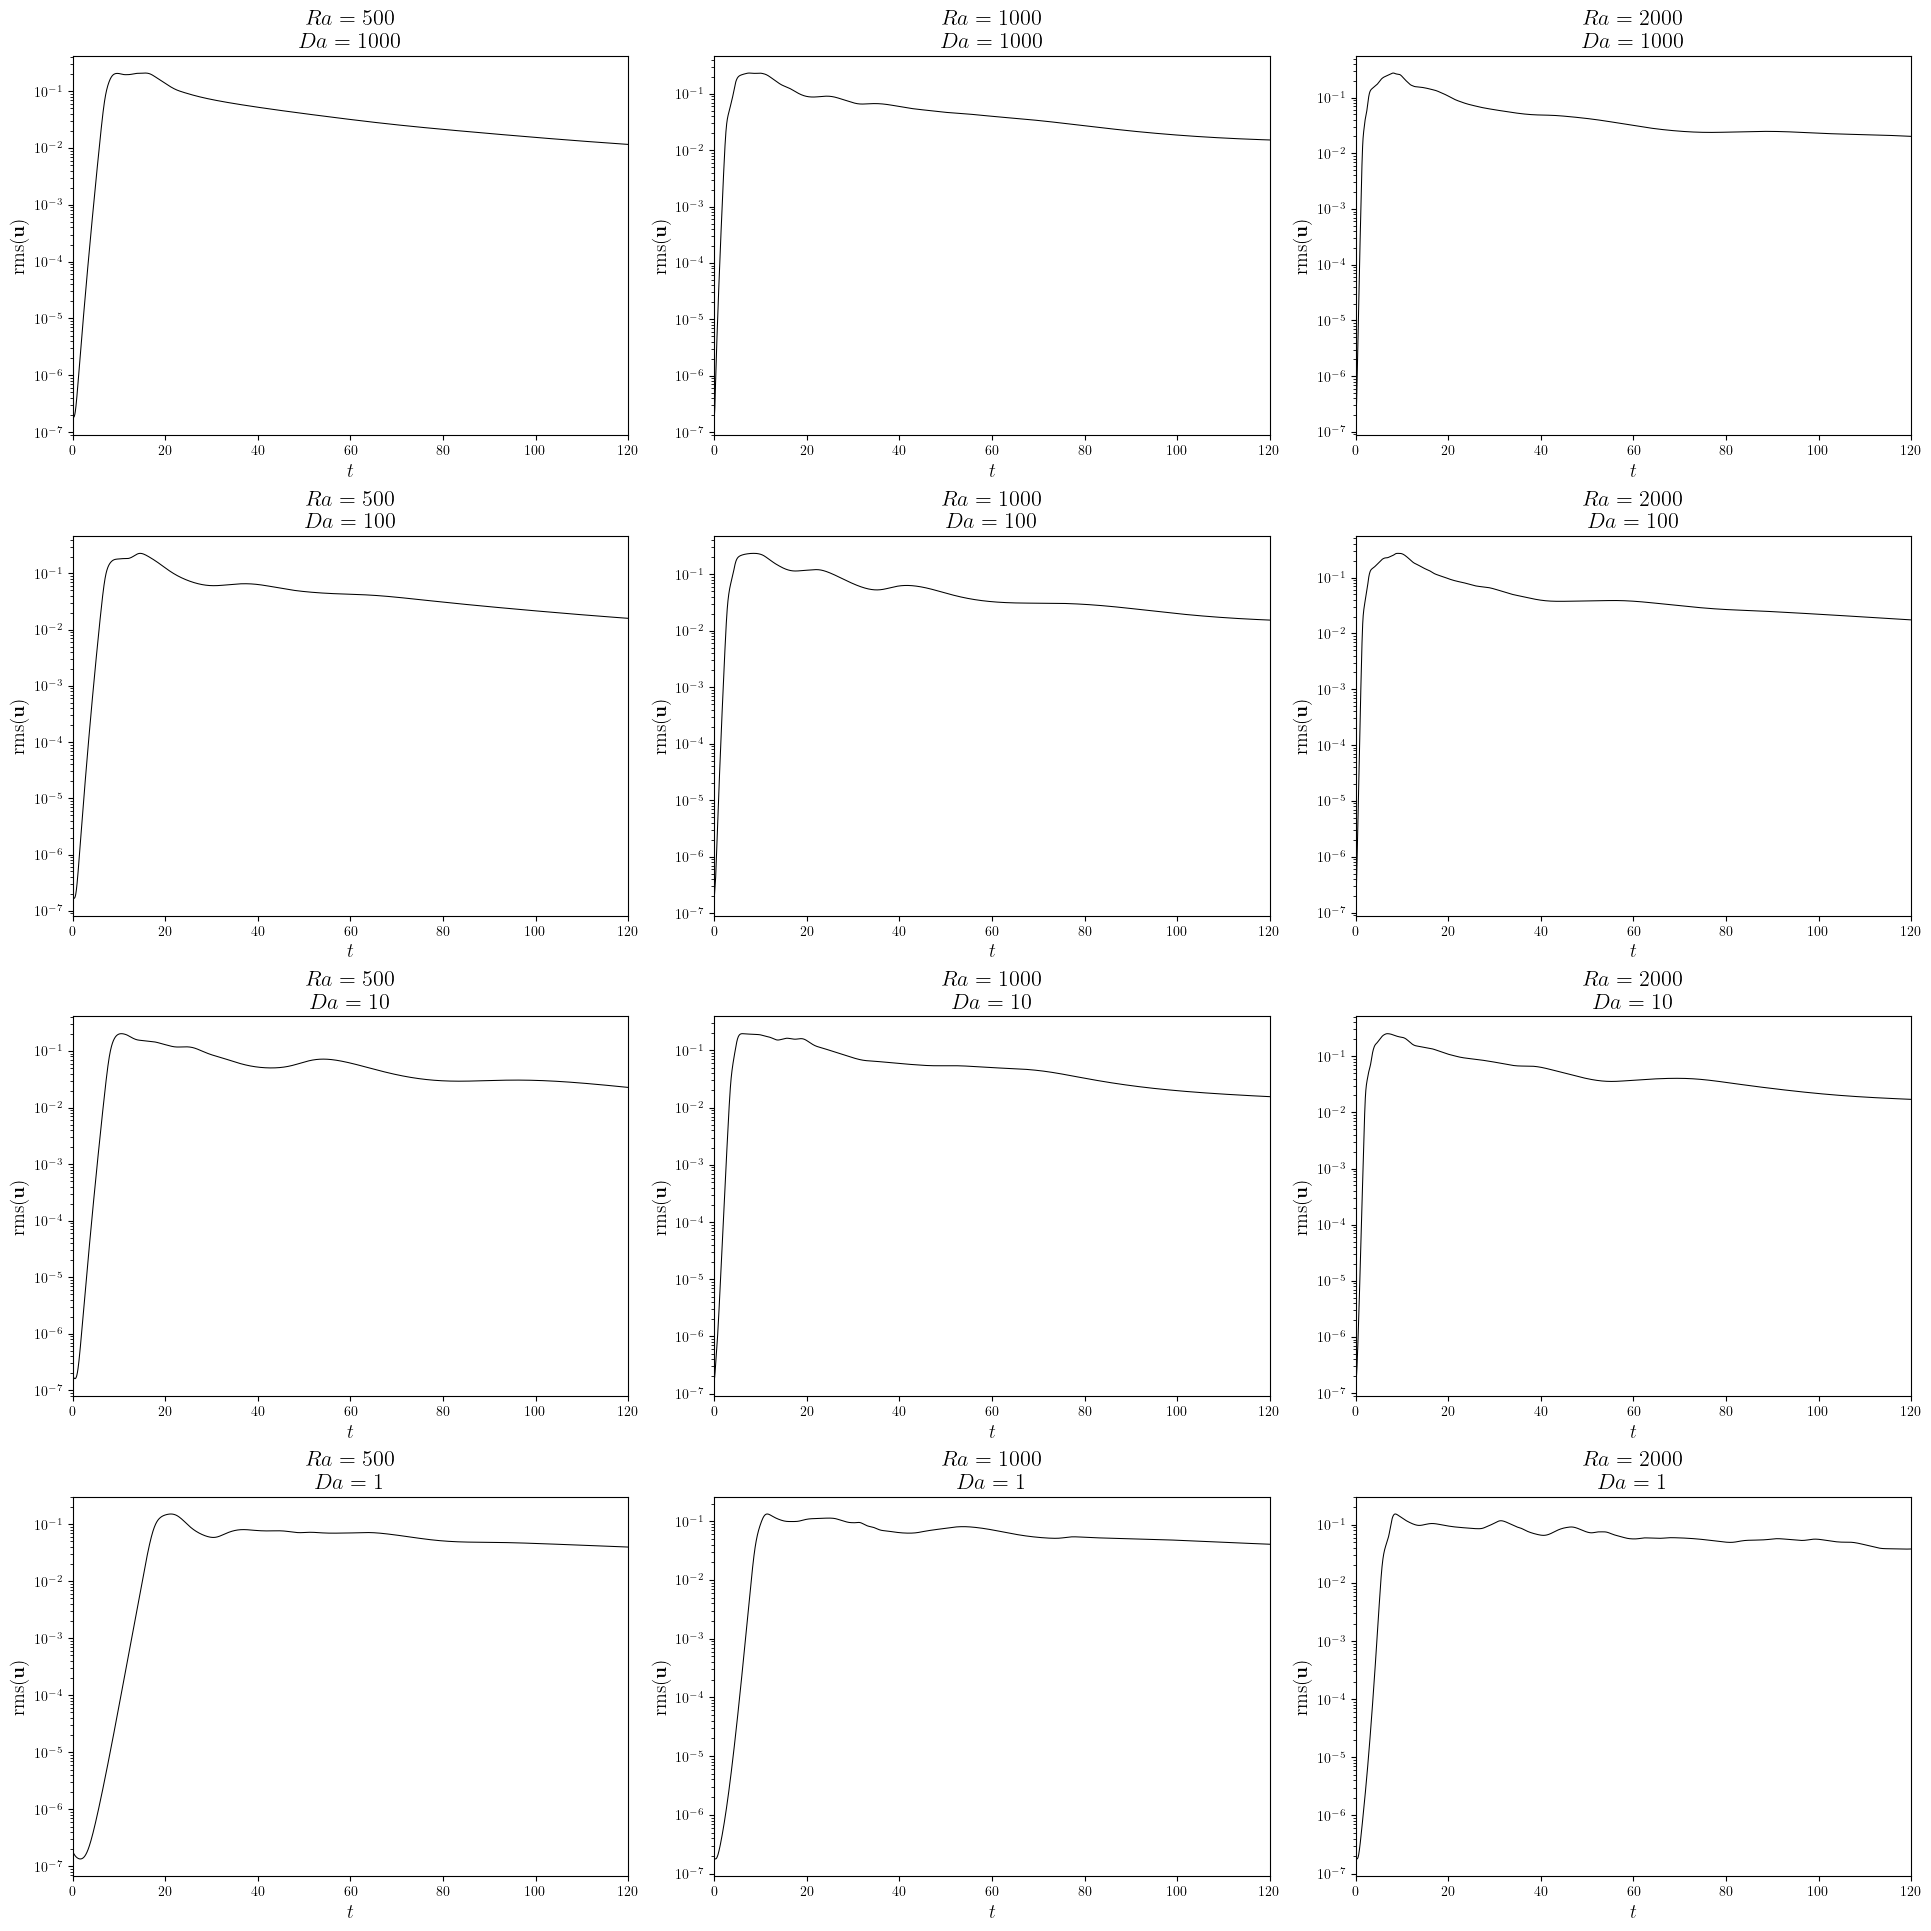

In [ ]:
SKIP_AVG = True

t_targets = (1.0, 3.0, 6.0, 9.0)

fPeak = 0.08
fRatioDash = 0.1
fRatioMax = 0.4
fRatio_expnt = 2
fRatio_slc = slice(10, None)

time_window = (0, 120)
n_cols = len(Ra_targets)
n_rows = int(len(simulations) / len(Ra_targets))
create_mfig = partial(create_multifigure, n_cols=n_cols, n_rows=n_rows)
mfig_mCmD, axs_mCmD, _ = create_mfig()
mfig_fMass, axs_fMass, _ = create_mfig()
mfig_uRMS, axs_uRMS, _ = create_mfig()
if not SKIP_AVG:
    mfig_cPlus, axs_cPlus, _ = create_mfig()
    mfig_cMinus, axs_cMinus, _ = create_mfig()
    mfig_sPlus, axs_sPlus, _ = create_mfig()
    mfig_fRatio, axs_fRatio, _ = create_mfig()

imap = lambda ix, iy: int((n_rows - 1 - iy) * n_cols + ix)
for (Ra, Da), sim in simulations.items():
    Ra_index = Ra_targets.index(Ra)
    Da_index = Da_targets.index(Da)
    idx = imap(Ra_index, Da_index)
    ttl = f'$Ra={as_int_if_poss(Ra)}$\n$Da={as_int_if_poss(Da)}$'
    kws = dict(title=ttl, x_label='$t$', x_lims=time_window)
    zeta0, aspect = sim['zeta0', 'aspect']
    Lx = aspect * 1
    mC, mD, f, uRMS = sim['mC', 'mD', 'f', 'uRMS']
    fZeta0, fZetaPlus, fZetaMinus = f.split()
    fMass = -(1/Lx) * derivative(mC.value_series, mC.time_series)
    plot_line(mfig_mCmD, axs_mCmD[idx],
        [(mC.time_series, mC.value_series), (mD.time_series, mD.value_series)],
        legend_labels=[f'$m_C$', '$m_D$'],
        **kws,
    )
    plot_line(
        mfig_fMass, axs_fMass[idx],
        [
            (fZeta0.time_series, [-np.sum(i) for i in fZeta0.value_series]), 
            (mC.time_series, fMass),
        ],
        y_lims=(0, fPeak),
        legend_labels=['$-F$', '$F_m$'],
        **kws,
    )
    plot_line(mfig_uRMS, axs_uRMS[idx],
        (uRMS.time_series, uRMS.value_series),
        y_label='$\mathrm{rms}(\mathbf{u})$',
        **kws,
    )
    axs_uRMS[idx].set_yscale('log')
    if SKIP_AVG:
        continue
    s, c = sim['s', 'c']
    zeta0_index = as_index(c.mesh.y_axis, zeta0)
    slcPlus = slice(zeta0_index, None)
    slcMinus = slice(0, zeta0_index)
    cPlus = NPyConstantSeries(
        grid_average(c.series, ('x', 'y'), (':', slcPlus)), c.time_series, 'cPlus',
    )
    cMinus = NPyConstantSeries(
        grid_average(c.series, ('x', 'y'), (':', slcMinus)), c.time_series, 'cMinus',
    )
    sPlus = NPyConstantSeries(
        grid_average(s.series, ('x', 'y'), (':', slcPlus)), s.time_series, 'sPlus',
    )
    plot_line(mfig_cPlus, axs_cPlus[idx],
        (cPlus.time_series, cPlus.value_series),
        y_label=f'$c^+$',
        **kws,
    )
    plot_line(mfig_cMinus, axs_cMinus[idx],
        (cMinus.time_series, cMinus.value_series),
        y_label=f'$c^-$',
        **kws,
    )
    plot_line(mfig_sPlus, axs_sPlus[idx],
        (sPlus.time_series, sPlus.value_series),
        y_label=f'$s^+$',
        **kws,
    )
    tFine = fZeta0.time_series
    cPlusFine = resample(cPlus.value_series, cPlus.time_series, tFine)
    cMinusFine = resample(cMinus.value_series, cMinus.time_series, tFine)
    fRatio = [
        -np.sum(flx) / (cp - cm)**fRatio_expnt 
        for flx, cp, cm in zip(fZeta0.value_series, cPlusFine, cMinusFine, strict=True)
    ]
    plot_line(mfig_fRatio, axs_fRatio[idx],
        (tFine[fRatio_slc], fRatio[fRatio_slc]),
        y_label=f'$-F/(c^+ - c^-)^{fRatio_expnt}$',
        y_lims=(0, fRatioMax),
        **kws,
    )

DIR_FIGS = False
if DIR_FIGS:
    names = ['mCmD', 'fMass', 'uRMS']
    if not SKIP_AVG:
        names.extend(('cPlus', 'cMinus', 'sPlus', 'fRatio'))
    mfigs = {
        f'{n}(t)': locals()[f'mfig_{n}'] for n in names
    }
    for n, mfig in mfigs.items():
        save_figure(n)(mfig)

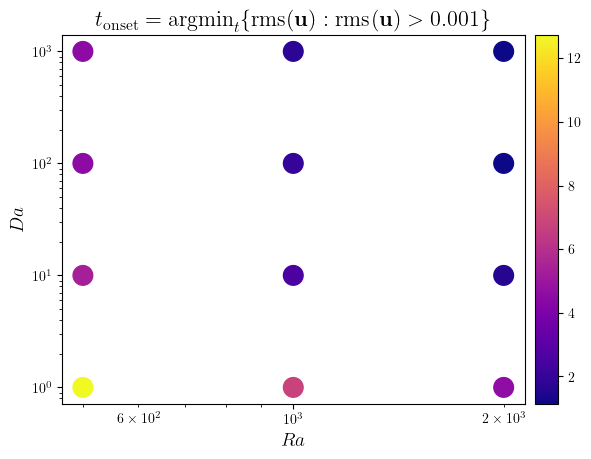

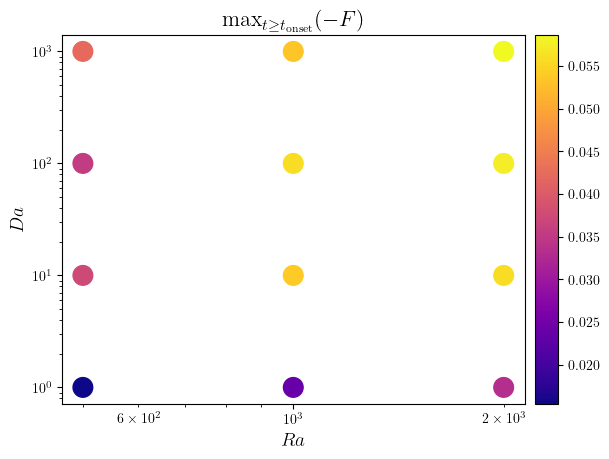

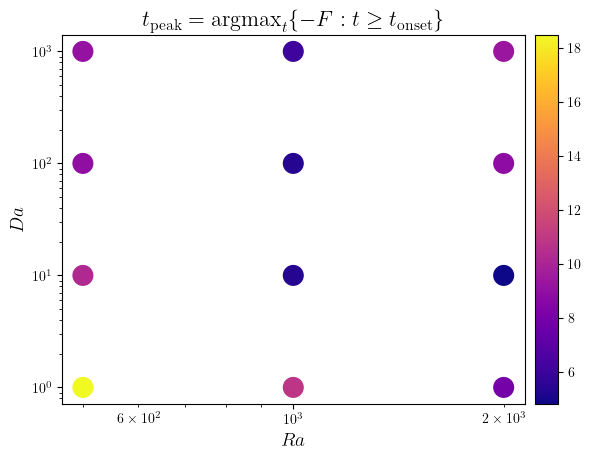

In [ ]:
from ipynb_utils import when_geq_first

uRMS_onset = 1e-3
Ra_points, Da_points = [], []
tOnsets, fPeaks, tPeaks = [], [], []

for (Ra, Da), sim in simulations.items(): 
    Ra_points.append(Ra)
    Da_points.append(Da)
    uRMS, f = sim['uRMS', 'f']
    fZeta0, fZetaPlus, fZetaMinus = f.split()
    tOnset = when_geq_first(uRMS.value_series, uRMS.time_series, uRMS_onset)
    tOnsets.append(tOnset)
    fZeta0Post_time_series = [t for t in fZeta0.time_series if t >= tOnset]
    fZeta0Post_value_series = [
        -np.sum(f) for t, f in zip(fZeta0.time_series, fZeta0.value_series) if t >= tOnset
    ]
    fPeak = np.max(fZeta0Post_value_series)
    fPeaks.append(fPeak)
    tPeak = when_geq_first(fZeta0Post_value_series, fZeta0Post_time_series, fPeak)
    tPeaks.append(tPeak)


kws = dict(
    size=200.0,
    cmap='plasma',
    x_label='$Ra$',
    y_label='$Da$',
)

fig, ax = plot_scatter(
    (Ra_points, Da_points, tOnsets), 
    title=f'$t_{{\mathrm{{onset}}}}=\mathrm{{argmin}}_t\{{\mathrm{{rms}}(\mathbf{{u}}):\mathrm{{rms}}(\mathbf{{u}})> {uRMS_onset}\}}$',
    **kws,
)
ax.set_xscale('log')
ax.set_yscale('log')
if DIR_FIGS: save_figure('tOnset')(fig)

fig, ax = plot_scatter(
    (Ra_points, Da_points, fPeaks), 
    title='$\max_{t\geq t_{{\mathrm{{onset}}}}}(-F)$',
    **kws,
)
ax.set_xscale('log')
ax.set_yscale('log')
if DIR_FIGS: save_figure('fPeak')(fig)

fig, ax = plot_scatter(
    (Ra_points, Da_points, tPeaks), 
    title=f'$t_{{\mathrm{{peak}}}}=\mathrm{{argmax}}_t\{{-F:t\geq t_{{\mathrm{{onset}}}}\}}$',
    **kws,
)
ax.set_xscale('log')
ax.set_yscale('log')
if DIR_FIGS: save_figure('tPeak')(fig)

